# Part A :- Concept Application

## 1. Create Synthetic Datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification


In [3]:
# Regression dataset
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Classification dataset
X_clf, y_clf = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2, random_state=42)

## 2. Train Simple Models & Visualize

### Regression (Linear Regression)

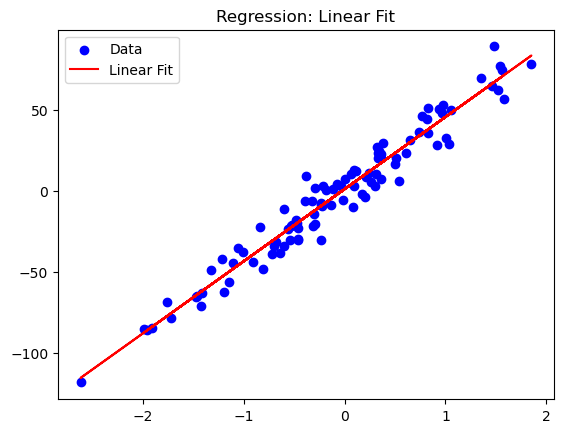

In [4]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg)
y_pred_reg = reg_model.predict(X_reg)

plt.scatter(X_reg, y_reg, color="blue", label="Data")
plt.plot(X_reg, y_pred_reg, color="red", label="Linear Fit")
plt.title("Regression: Linear Fit")
plt.legend()
plt.show()


### Classification (Logistic Regression)

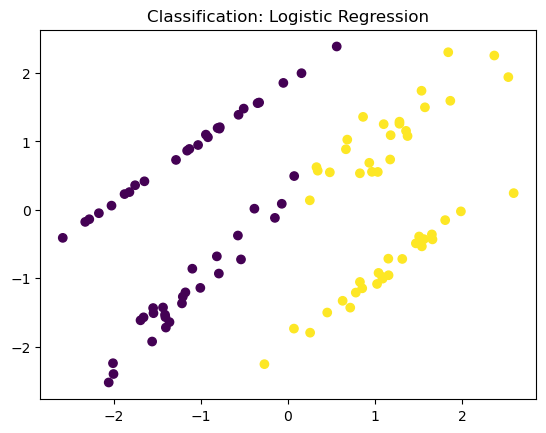

In [9]:
from sklearn.linear_model import LogisticRegression

clf_model = LogisticRegression()
clf_model.fit(X_clf, y_clf)
y_pred_clf = clf_model.predict(X_clf)

plt.scatter(X_clf[:, 0], X_clf[:, 1], c=y_pred_clf, cmap="viridis")
plt.title("Classification: Logistic Regression")
plt.show()

## 3. Identify Regression vs Classification
### Regression: 
- Target variable is continuous (e.g., real numbers like prices, temperatures).

### Classification: 
- Target variable is categorical/discrete (e.g., labels like 0/1, cat/dog).

## 4. Manual Regression Model

In [13]:
# Simple linear equation: y = m*x + c
m, c = 2, 5
y_manual_pred = m * X_reg.flatten() + c

# Compute Mean Squared Error
mse = np.mean((y_reg - y_manual_pred)**2)
print("Manual Regression MSE:", mse)


Manual Regression MSE: 1616.4678867436921


## 5. Manual Classification Logic

In [17]:
# Threshold-based classification
threshold = 0.5
y_manual_pred = np.where(X_clf[:, 0] > threshold, 1, 0)

# Compute Accuracy
accuracy = np.mean(y_clf == y_manual_pred)
print("Manual Classification Accuracy:", accuracy*100,"%")

Manual Classification Accuracy: 90.0 %


## 6. Compare outputs of regression vs classification:

Regression and classification differ fundamentally in the type of outputs they produce. Regression models generate continuous values, meaning the predictions can take on any real number within a range. This makes them suitable for tasks like predicting house prices, stock values, or temperatures, where the outcome is not restricted to categories but instead varies smoothly. Classification models, on the other hand, produce discrete labels, such as 0/1 or categorical classes like "spam" vs "not spam." These outputs are inherently categorical and are used when the goal is to assign data points into distinct groups.

The use cases for each approach reflect this difference. Regression is applied in scenarios where the target variable represents a measurable quantity, often tied to forecasting or estimation problems. For example, predicting sales revenue, estimating the lifespan of a machine, or modeling population growth are regression tasks. Classification is used when the problem involves decision-making between categories, such as medical diagnosis (disease vs no disease), fraud detection (fraudulent vs legitimate transaction), or image recognition (cat vs dog).

# Part B :- Stretch Problem

## 1. Simulate Bias–Variance Tradeoff

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

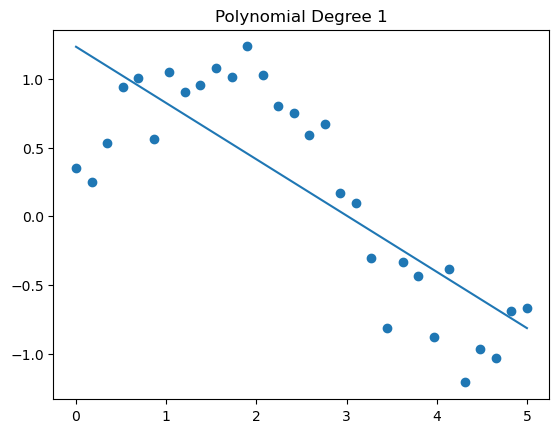

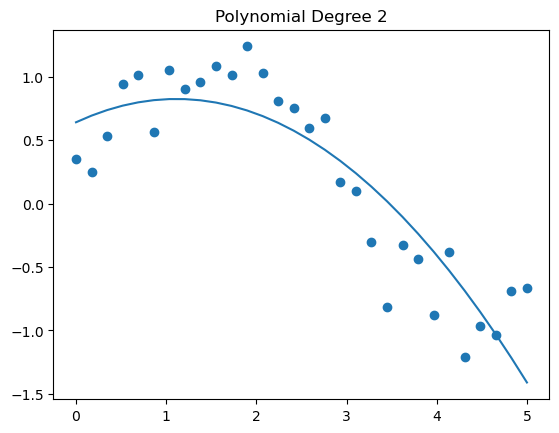

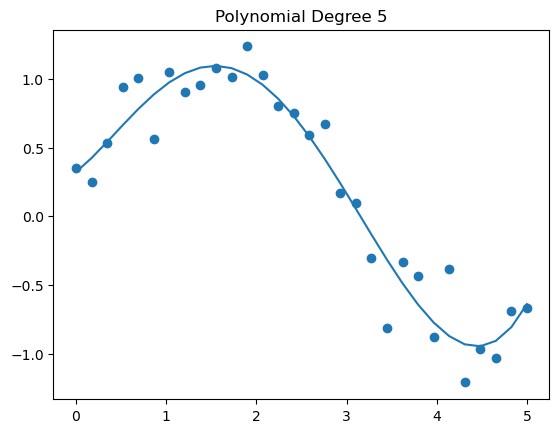

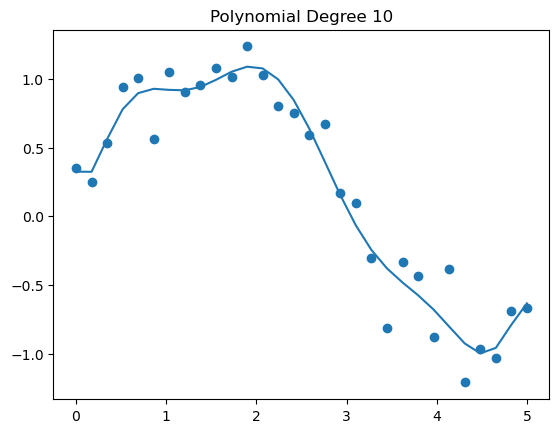

In [23]:
np.random.seed(0)
X = np.linspace(0, 5, 30).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.randn(30) * 0.2

degrees = [1, 2, 5,10]
errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X)
    error = mean_squared_error(y, y_pred)
    errors.append(error)

    plt.scatter(X, y)
    plt.plot(X, y_pred)
    plt.title(f"Polynomial Degree {d}")
    plt.show()

## 2. Plot Training Error vs Model Complexity

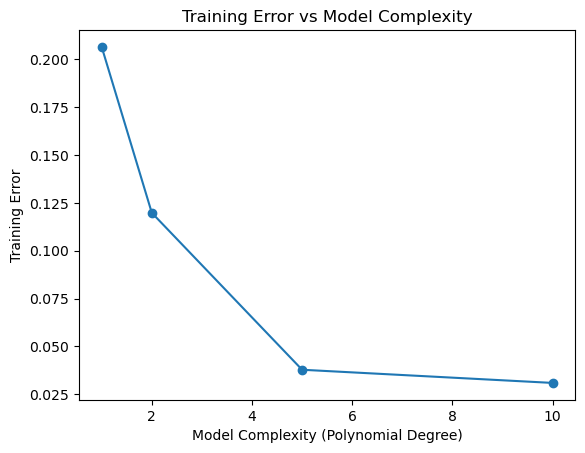

In [24]:
plt.plot(degrees, errors, marker='o')
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Training Error")
plt.title("Training Error vs Model Complexity")
plt.show()

## 3. Explanation

### 1. What is bias?
Bias is the error caused by using a model that is too simple to capture the true pattern in data. High-bias models make strong assumptions and often underfit. For example, a degree-1 polynomial may miss curved relationships.

### 2. What is variance?
Variance is the error caused when a model becomes too sensitive to training data. High-variance models fit noise along with actual patterns and may overfit. For example, a high-degree polynomial can change sharply between points.

### 3. Where does the optimal model lie?
The optimal model lies between underfitting and overfitting, where both bias and variance are balanced. It captures the main pattern without fitting noise. In this example, degree 2 often gives a better balance than degree 1 or degree 5.